Reference step size: 0.01


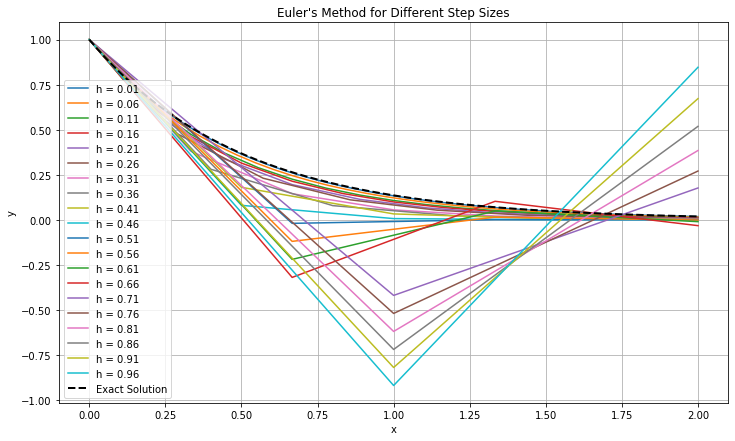


Step size h = 0.01
x		Error (current run vs first run)
0.00		0.000000
0.01		0.000000
0.02		0.000000
0.03		0.000000
0.04		0.000000
0.05		0.000000
0.06		0.000000
0.07		0.000000
0.08		0.000000
0.09		0.000000
0.10		0.000000
0.11		0.000000
0.12		0.000000
0.13		0.000000
0.14		0.000000
0.15		0.000000
0.16		0.000000
0.17		0.000000
0.18		0.000000
0.19		0.000000
0.20		0.000000
0.21		0.000000
0.22		0.000000
0.23		0.000000
0.24		0.000000
0.25		0.000000
0.26		0.000000
0.27		0.000000
0.28		0.000000
0.29		0.000000
0.30		0.000000
0.31		0.000000
0.32		0.000000
0.33		0.000000
0.34		0.000000
0.35		0.000000
0.36		0.000000
0.37		0.000000
0.38		0.000000
0.39		0.000000
0.40		0.000000
0.41		0.000000
0.42		0.000000
0.43		0.000000
0.44		0.000000
0.45		0.000000
0.46		0.000000
0.47		0.000000
0.48		0.000000
0.49		0.000000
0.50		0.000000
0.51		0.000000
0.52		0.000000
0.53		0.000000
0.54		0.000000
0.55		0.000000
0.56		0.000000
0.57		0.000000
0.58		0.000000
0.59		0.000000
0.60		0.000000
0.61		0.000000
0.62		0.000000

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#function representing dy/dx = -2y
def f(x, y):
    return -2 * y

#exact solution for comparison
def exact_solution(x):
    return np.exp(-2 * x)

#euler's method
def euler_method(h, x_start=0, x_end=2, y0=1):
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    y_values[0] = y0

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    return x_values, y_values

#step sizes from 0.01 to 1.00 in steps of 0.05
step_sizes = np.arange(0.01, 1.01, 0.05)

all_runs = []

#running euler for all step sizes
for h in step_sizes:
    x_vals, y_vals = euler_method(h)
    all_runs.append((h, x_vals, y_vals))

#reference
h_ref, x_ref, y_ref = all_runs[0]

print("Reference step size:", h_ref)

#plot
plt.figure(figsize=(12, 7))

for h, x_vals, y_vals in all_runs:
    plt.plot(x_vals, y_vals, label=f"h = {h:.2f}")

#plot of exact solution
x_exact = np.linspace(0, 2, 500)
y_exact = exact_solution(x_exact)
plt.plot(x_exact, y_exact, 'k--', linewidth=2, label="Exact Solution")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method for Different Step Sizes")
plt.legend()
plt.grid(True)
plt.show()

#error comparison of current run vs first run
for h, x_vals, y_vals in all_runs:
    #interpolate current run onto reference x-points
    y_interp = np.interp(x_ref, x_vals, y_vals)

    pointwise_error = np.abs(y_interp - y_ref)
    total_error = np.sum(pointwise_error)

    print(f"\nStep size h = {h:.2f}")
    print("x\t\tError (current run vs first run)")
    for i in range(len(x_ref)):
        print(f"{x_ref[i]:.2f}\t\t{pointwise_error[i]:.6f}")

    print(f"Total accumulated error for h = {h:.2f}: {total_error:.6f}")